<a href="https://colab.research.google.com/github/raid4shoots-sudo/chaine-of-life/blob/main/TP2_Partie2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2-Introduction au Machine Learning. Parte 2: Classification supervisée avec un modèle d'apprentissage automatique simple.

**Nom et prénom:** Khennane Raid

# But de TP: Créer et entrainer un modèle de classification simple.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/TP_AI/iris.csv')

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


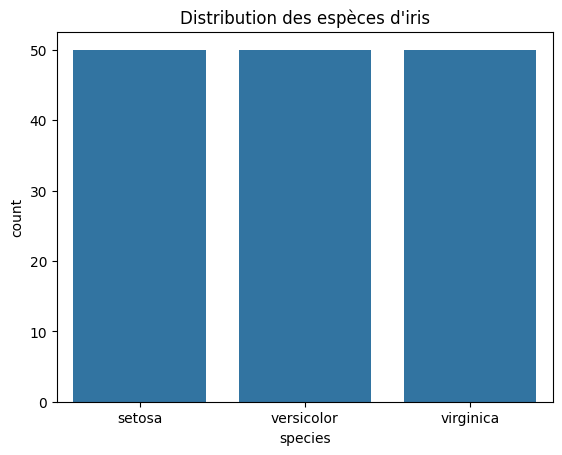

In [6]:
sns.countplot(x='species', data=df)                                               # Visualiser combien d'exemples il y a dans chaque espèce.
plt.title('Distribution des espèces d\'iris')
plt.show()

In [7]:
# Séparer les caractéristique et la cible
X = df.drop('species', axis=1)                                                    # X contient toutes les colonnes sauf 'species'.
y = df['species']                                                                 # y contient seulement la colonne 'species'.

In [8]:
# Diviser les données en ensemble d'entrainement (80%) et de test (20%).
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [9]:
# Normaliser les caractéristique
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)                                           # Calculer moyenne/écart-type sur les données d'entraînement et transformer.
X_test = scaler.transform(X_test)                                                 # Transformer les données de test avec les mêmes paramètres.

In [10]:
# Créer le modèle KNN
knn = KNeighborsClassifier(n_neighbors=3)

In [11]:
# Entrainer le modèle
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [12]:
# Prédire les classes de l'ensemble de test
y_pred = knn.predict(X_test)

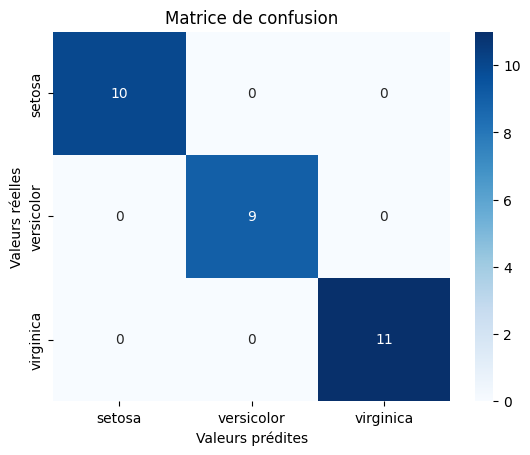

In [13]:
# Afficher la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues',fmt='d', xticklabels=df['species'].unique(), yticklabels=df['species'].unique())
plt.title('Matrice de confusion')
plt.xlabel('Valeurs prédites')
plt.ylabel('Valeurs réelles')
plt.show()

In [14]:
# Calculer l'exactitude
accuracy = accuracy_score(y_test, y_pred)
print(f'Exactitude du modèle: , {accuracy*100:.2f}%')

Exactitude du modèle: , 100.00%


In [15]:
# Afficher le rapport de classification
print('Rapport de classification: \n', classification_report(y_test, y_pred))

Rapport de classification: 
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

